## Benchmark Functions for Genetic Algorithm Evaluation

In this project, three benchmark optimization functions are selected from the standard test functions for optimization to evaluate the behavior and performance of genetic algorithms under increasing levels of complexity. These functions are widely used in the optimization literature and provide different characteristics such as unimodality, nonlinearity, and multimodality.

---

### Sphere Function (Simple, Unimodal)

The Sphere function is one of the simplest continuous optimization test functions. It is unimodal and convex, with a single global minimum, making it suitable as a baseline to verify the correctness of the genetic algorithm implementation.

$$
f(\mathbf{x}) = \sum_{i=1}^{n} x_i^2
$$

The global minimum is located at:
$$
\mathbf{x} = \mathbf{0}, \quad f(\mathbf{x}) = 0
$$

Due to its simple landscape, the Sphere function is primarily used as a sanity check and baseline experiment.


In [49]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import copy


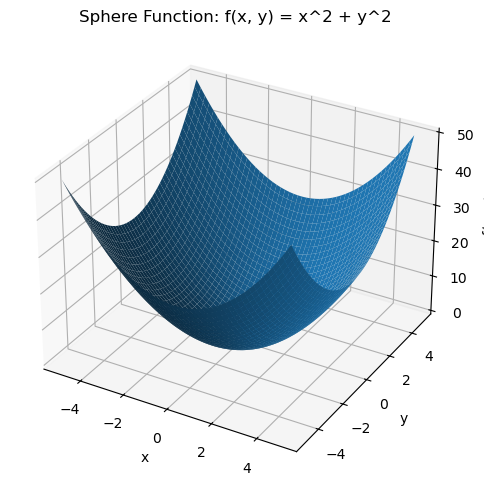

In [50]:
#Sphere function (3D)

def sphere(x, y):
    return x**2 + y**2

x = np.linspace(-5, 5, 250)
y = np.linspace(-5, 5, 250)
X, Y = np.meshgrid(x, y)
Z = sphere(X, Y)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True)

ax.set_title("Sphere Function: f(x, y) = x^2 + y^2")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
plt.tight_layout()
plt.show()


### Initialization ###
1. Random initialization
2. Exampler initialization

In [51]:
# 1.Random initialization:
def initilization_random(population_size):
    return [np.random.uniform(-5, 5, size=2) for _ in range(population_size)]

# 2. Exampler initialization:
def initialization_exemplar(population_size, exemplar=np.array([0.0, 0.0]), sigma=0.5, exemplar_ratio=0.3):
    population = []

    num_exemplar = int(population_size * exemplar_ratio)
    num_random   = population_size - num_exemplar

    # --- exemplar-based individuals ---
    for _ in range(num_exemplar):
        chromosome = exemplar + np.random.normal(0, sigma, size=2)
        chromosome = np.clip(chromosome, -5, 5)  # keep bounds
        population.append(chromosome)

    # --- random individuals ---
    for _ in range(num_random):
        chromosome = np.random.uniform(-5, 5, size=2)
        population.append(chromosome)

    return population


### Fitness Score ###

In [52]:
# This function goes over each chromosome, evaluate it, then return sorted answers
def fitness_score(population):

    scores = []

    # Fitness function:
    for chromosome in population:
        fitness_func_value = sphere(chromosome[0],chromosome[1])
        scores.append(1.0/(fitness_func_value + 0.01))


    # Use numpy array to sort the fitness scores in descending order.
    scores, pop = np.array(scores), np.array(population.copy())
    inds = np.argsort(scores) 
    scores = list(scores[inds][::-1])
    pop = list(pop[inds,:][::-1])
    return scores, pop


### Selection ###
1. Proportional selection
2. Tournament selection

In [53]:
# 1 .Proportional selection (roulette wheel selection)
def selection_proportional(scores,pop_after_fit):
    population_nextgen = []
    
    # elitism
    population_nextgen.append(pop_after_fit[0].copy())
    population_nextgen.append(pop_after_fit[0].copy())

    # pick our remaining parents (so two for each child)
    max_val = np.sum(scores) # This is like the full size of the roulette wheel.
    for i in range(1,len(scores)):
        for k in range(2):   # We select 2 parent for each child in the next generation.
            pick = random.uniform(0, max_val)
            current = 0
            for j in range(len(scores)): 
                current += scores[j]
                if current > pick: 
                    break 
            population_nextgen.append(pop_after_fit[j].copy()) 
    return population_nextgen

# 2. Tournament selection
def selection_tournament(scores, pop_after_fit, tournament_ratio=0.1):
    population_nextgen = []

    pop_size = len(pop_after_fit)
    tournament_size = max(2, int(pop_size * tournament_ratio))

    # Elitism (same as proportional)
    population_nextgen.append(pop_after_fit[0].copy())
    population_nextgen.append(pop_after_fit[0].copy())

    # Tournament selection:
    for i in range(1, pop_size):
        for k in range(2):  # select 2 parents (same structure as before)
            # randomly pick tournament_size individuals
            competitors_idx = np.random.choice(
                range(pop_size), tournament_size, replace=False
            )

            # select the best one among them
            best_idx = competitors_idx[0]
            best_score = scores[best_idx]

            for idx in competitors_idx[1:]:
                if scores[idx] > best_score:
                    best_idx = idx
                    best_score = scores[idx]

            population_nextgen.append(pop_after_fit[best_idx].copy())

    return population_nextgen

### Crossover ###
1. One points crossover
2. Arithmetic crossover

In [54]:
# 1. One points crossover:
def crossover_one_point(pop_after_sel,population_size):
    # This is the frist child(elite)
    population_nextgen = [] 
    population_nextgen.append(pop_after_sel[0].copy())

    # Iterate through the rest chromosomes.
    # Each parent only has 2 elements. [a,b] a,b are from -5 to 5. 
    for i in range(1,population_size):
        child = pop_after_sel[2*i+0].copy()
        parent2 = pop_after_sel[2*i+1].copy()
        location = np.random.randint(0,2) # Generate a random number 0 or 1 as the location to cross
        child[location] = parent2[location] 
        population_nextgen.append(child) 
    return population_nextgen

# 2. Arithmetic crossover
def crossover_arithmetic(pop_after_sel, population_size, alpha=0.5):
    # The first child is the elite
    population_nextgen = []
    population_nextgen.append(pop_after_sel[0].copy())

    # Generate the rest of the children
    # Each chromosome has 2 real-valued genes: [x, y]
    for i in range(1, population_size):
        parent1 = pop_after_sel[2*i].copy()
        parent2 = pop_after_sel[2*i + 1].copy()

        # Arithmetic crossover
        child = alpha * parent1 + (1 - alpha) * parent2

        population_nextgen.append(child)

    return population_nextgen


### Mutation ###
1. Uniform mutation
2. Gaussian mutation

In [55]:
# Uniform mutation
def mutation_uniform(pop_after_cross,mutation_rate,population_size):
    # We don't apply mutation to the elite
    population_nextgen = []
    population_nextgen.append(pop_after_cross[0].copy())


    for i in range(1,population_size): 
        chromosome = pop_after_cross[i].copy()
        for j in range(len(chromosome)): 
            if random.random() < mutation_rate:
                chromosome[j]= ((( np.random.rand() - 0.5 ) * 2.0 ) * 5.0 ) # Creates a new random value in range [-5, 5]. Replace the original value with this new value.
        population_nextgen.append(chromosome.copy())
    return population_nextgen

# Gaussian mutation
def mutation_gaussian(pop_after_cross, mutation_rate, population_size, sigma=0.1):
    # We don't apply mutation to the elite
    population_nextgen = []
    population_nextgen.append(pop_after_cross[0].copy())

    for i in range(1, population_size):
        chromosome = pop_after_cross[i].copy()

        for j in range(len(chromosome)):
            if random.random() < mutation_rate:
                # Gaussian perturbation around the current value
                chromosome[j] += np.random.normal(0, sigma)

                # Optional: clip to domain [-5, 5]
                chromosome[j] = np.clip(chromosome[j], -5.0, 5.0)

        population_nextgen.append(chromosome.copy())

    return population_nextgen

### Main function ###

In [56]:
from tqdm import tqdm_notebook as tqdm

# this is our main function
def generations(population_size,mutation_rate,generation_count):

    # ----------------------------------------------------------------------------------
    # Termination condition params
    
    use_stagnation_termination = False   # <-------------Where we can choose to turn on/off the stagnation termination
    patience = 30                       # We will terminate if there is no improvement after 30 generations
    no_improve_counter = 0
    best_so_far = None
    # ----------------------------------------------------------------------------------

    best_chromo = []
    best_scores = []

    # ****************************************************************************
    # Two different initialization (turn off one of them)

    # 1
    population_next_generation = initilization_random(population_size)

    # 2
    # population_next_generation = initialization_exemplar(population_size, exemplar=np.array([0.0, 0.0]), sigma=0.5, exemplar_ratio=0.3)

    # ****************************************************************************


    stats_min = np.zeros(generation_count)
    stats_avg = np.zeros(generation_count)
    stats_max = np.zeros(generation_count)

    # lets store the points from generation to generation
    stored_points = []
    
    # this is the number of generations
    for i in tqdm(range(generation_count)):
        # evaluate
        scores, pop_after_fit = fitness_score(population_next_generation)

        # &&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
        # Two kinds of selections:

        # 1. proportional_selection:
        # pop_sel = selection_proportional(scores,pop_after_fit)

        # 2. Tournament selection:
        pop_sel = selection_tournament(scores, pop_after_fit)

        # &&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&

        # ****************************************************************************
        # Two kinds of crossover:

        # 1. one_point_crossover:
        # pop_after_cross = crossover_one_point(pop_sel,population_size)

        # 2 Arithmetic crossover
        pop_after_cross = crossover_arithmetic(pop_sel,population_size)
        # ****************************************************************************

        # &&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
        # Two kinds of mutation

        # 1. Uniform mutation:
        # population_next_generation = mutation_uniform(pop_after_cross,mutation_rate,population_size)

        # 2. Gaussian mutation:
        population_next_generation = mutation_gaussian(pop_after_cross,mutation_rate,population_size)
        # &&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&




        # I do one more scoring as I track values from epoch to epoch (could just change where its at also ;-)
        scores, pop_after_fit = fitness_score(population_next_generation)
        stored_points.append( pop_after_fit ) # remember each epoch
        best_chromo.append(pop_after_fit[0].copy())
        best_scores.append(scores[0].copy())        
        stats_min[i] = np.min(scores)
        stats_max[i] = np.amax(scores)
        stats_avg[i] = np.mean(scores)        

        # ----------------------------------------------------------------------------------------------------------------
        # Stagnation-based termination：（Only execute this when we use stagnation termination condition）
        if use_stagnation_termination:
            if best_so_far is None or scores[0] < best_so_far:
                best_so_far = scores[0]
                no_improve_counter = 0
            else:
                no_improve_counter += 1

            if no_improve_counter >= patience:
                print(f"Early stopping at generation {i} (no improvement for {patience} generations)")
                break
        # ----------------------------------------------------------------------------------------------------------------
    return best_chromo,best_scores,stats_min,stats_avg,stats_max,stored_points

### Run the main function ###
1. Termination condition 1: The fixed number of generations

In [57]:
population_size = 100 # number of individuals
generation_number = 100 # number of generations
best_chromo,best_scores,stats_min,stats_avg,stats_max,stored_points = generations(population_size=population_size,mutation_rate=0.05,generation_count=generation_number)

C:\Users\Biao Wang\AppData\Local\Temp\ipykernel_16488\155004275.py:38: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(generation_count)):


  0%|          | 0/100 [00:00<?, ?it/s]

### Plot ### 

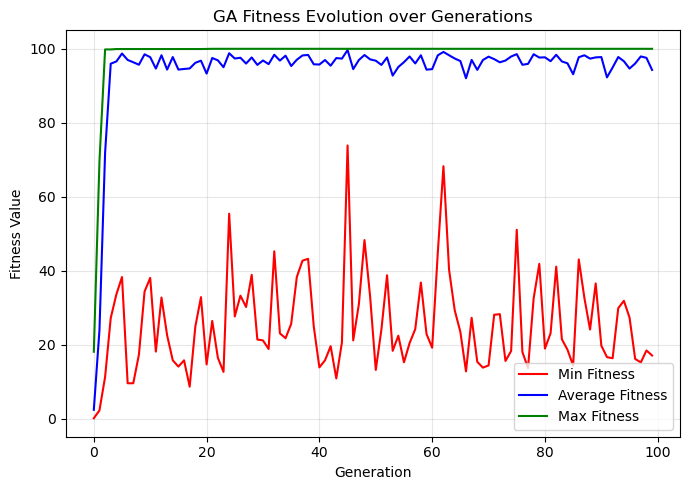

*******************************************
The best scores is: [18.12757435238254, 69.60722508040756, 99.83105740905314, 99.83105740905314, 99.93503680619564, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.94050770247212, 99.963633785807, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.99922039187793, 99.999

In [58]:


plt.figure(figsize=(7,5))

plt.plot(stats_min, 'r', label='Min Fitness')
plt.plot(stats_avg, 'b', label='Average Fitness')
plt.plot(stats_max, 'g', label='Max Fitness')

plt.xlabel('Generation')
plt.ylabel('Fitness Value')
plt.title('GA Fitness Evolution over Generations')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("*******************************************")
print("The best scores is: {}".format(best_scores))
print("The best chromosome is:")
print(best_chromo)


### Repeat experiment ###


In [59]:
def run_ga_10_times(
    num_runs=10,
    population_size=100,
    generation_number=100,
    mutation_rate=0.1,
    seed_start=0
):
    final_best_scores = []

    for i in range(num_runs):
        np.random.seed(seed_start + i)

        best_chromo, best_scores, _, _, _, _ = generations(
            population_size=population_size,
            mutation_rate=mutation_rate,
            generation_count=generation_number
        )

        # Got the final best score (The elite)
        final_best_scores.append(best_scores[-1])

    final_best_scores = np.array(final_best_scores)
    print(final_best_scores)

    avg = final_best_scores.mean()
    std = final_best_scores.std(ddof=1)

    return avg, std, final_best_scores


In [60]:
population_size = 100
generation_number = 100

avg, std, scores = run_ga_10_times(
    num_runs=10,
    population_size=population_size,
    generation_number=generation_number,
    mutation_rate=0.1
)

print(f"Best fitness: {avg:.4f} ({std:.4f})")

C:\Users\Biao Wang\AppData\Local\Temp\ipykernel_16488\155004275.py:38: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(generation_count)):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

[99.99994273 99.99001358 99.99999523 99.99998168 99.99948198 99.99999987
 99.99998098 99.99999985 99.99931887 99.99968212]
Best fitness: 99.9988 (0.0031)


### Animation ###

In [ ]:
from IPython import display
import pylab as pl
from matplotlib.patches import Ellipse
from sklearn import datasets
import numpy as np
import time
from sklearn import datasets

def my_func(x, y):
    return x*x + y*y

fig, ax = pl.subplots(nrows = 1, ncols = 1, figsize=(7, 5))

for t in range(len(stored_points)):    
    
    pl.clf() 
        
    # get this set of points out
    data = stored_points[t] 
    
    # plot  
    for i in range(len(data)):
        pl.scatter(data[i][0], data[i][1], edgecolor='b', alpha=0.3)  
        
    # Sphere
    a = np.arange(-5, 5, 0.05)
    b = np.arange(-5, 5, 0.05)
    x, y = np.meshgrid(a, b)
    z = my_func(x, y)
    # pl.contour(x, y, z, levels=np.logspace(-9, 9, 50), cmap='jet', alpha=0.4)    
    pl.contour(
    x, y, z,
    levels=np.logspace(-9, 9, 50),
    cmap='jet',
    alpha=0.4)

    
    # animation, so pause it!
    display.clear_output(wait=True)
    display.display(pl.gcf())
    plt.xlim(-5, 5)
    plt.ylim(-5, 5) 
    time.sleep(0.01)     

In [ ]:
# (optional but recommended in Jupyter)
# %matplotlib widget  # or: from matplotlib import rc; rc('animation', html='jshtml')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display

def my_func(x, y):
    return x*x + y*y

def animate_himmelblau(stored_points, interval_ms=30, edgealpha=0.3):
    # 1) Set up figure/axes once
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title("Sphere function – animated points")

    # 2) Precompute the contour once (expensive)
    a = np.arange(-5, 5, 0.05)
    b = np.arange(-5, 5, 0.05)
    x, y = np.meshgrid(a, b)
    z = my_func(x, y)
    # ax.contour(x, y, z, levels=np.logspace(-9, 9, 50), cmap='jet', alpha=0.4)
    pl.contour(
    x, y, z,
    levels=np.logspace(-9, 9, 50),
    cmap='jet',
    alpha=0.4)

    # 3) Create an empty scatter artist we'll update per-frame
    scat = ax.scatter([], [], edgecolor='b', facecolors='none', alpha=edgealpha)

    # 4) Update function: only mutate existing artists—no clearing!
    def update(frame_idx):
        data = np.asarray(stored_points[frame_idx])
        # data expected shape: (N, 2)
        if data.size == 0:
            scat.set_offsets(np.empty((0, 2)))
        else:
            scat.set_offsets(data[:, :2])
        return (scat,)

    # 5) Create animation
    anim = FuncAnimation(
        fig,
        update,
        frames=len(stored_points),
        interval=interval_ms,
        blit=False  # blit=True can be faster, but is finicky across Jupyter backends
    )

    # 6) Display smoothly in Jupyter (JS-based HTML animation)
    try:
        from matplotlib import rc
        rc('animation', html='jshtml')
        display(anim)
    except Exception:
        # Fallback to widget backend display if available
        display(anim)

    return anim

# Example usage:
anim = animate_himmelblau(stored_points, interval_ms=30)